# 06 — Robustness Checks, and a Retraction

Four rounds of review, documented in full in `../docs/robustness_checks.md`. This notebook walks through the checks with real output: a matched-penalty sweep, an edge-overlap sensitivity test, continuous capacity analysis with leave-one-out, and two independent null models. **The headline result of this notebook is a retraction, not a confirmation** — an early finding that real floods hit network "chokepoints" did not survive testing and was withdrawn. Building the second null model (A2) also surfaced a genuine pathing bug in the severe-scenario pipeline, fixed and re-tested (§7c) — the fix and its outcome are reported below alongside the retraction, the same way the rest of this project reports anything else: with the actual numbers, not softened.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PROC = Path('../data/processed')

## Matched-penalty sweep

The proxy and Sentinel-1 moderate scenarios originally used different penalty multipliers (×2.5 vs ×5) — individually defensible, but not a controlled comparison. This reruns both at identical multipliers.

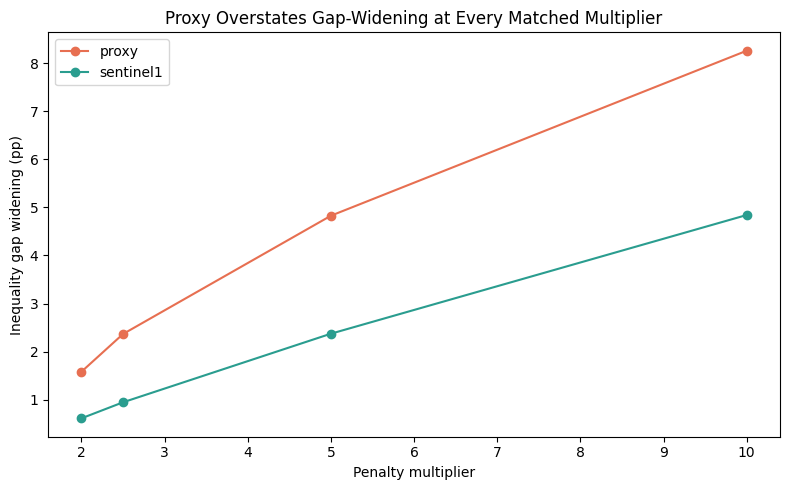

,layer,multiplier,gap_widening_pp
1,proxy,2.0,1.583764
2,proxy,2.5,2.367841
3,proxy,5.0,4.826553
4,proxy,10.0,8.255357
5,sentinel1,2.0,0.615619
6,sentinel1,2.5,0.949088
7,sentinel1,5.0,2.374640
8,sentinel1,10.0,4.841070


In [2]:
sweep = pd.read_csv(DATA_PROC / 'penalty_sensitivity_sweep.csv')
sweep = sweep[sweep['layer'].isin(['proxy', 'sentinel1'])]

fig, ax = plt.subplots(figsize=(8, 5))
for layer, color in [('proxy', '#e76f51'), ('sentinel1', '#2a9d8f')]:
    sub = sweep[sweep['layer'] == layer].sort_values('multiplier')
    ax.plot(sub['multiplier'], sub['gap_widening_pp'], marker='o', label=layer, color=color)
ax.set_xlabel('Penalty multiplier')
ax.set_ylabel('Inequality gap widening (pp)')
ax.set_title('Proxy Overstates Gap-Widening at Every Matched Multiplier')
ax.legend()
plt.tight_layout()
plt.show()

sweep[['layer', 'multiplier', 'gap_widening_pp']]

**Result:** the proxy overstates gap-widening by 1.7–2.6× at every multiplier tested. The direction (flooding widens the chronic gap) is unanimous across all 8 scenarios — the finding got stronger under scrutiny, not weaker.

## Edge-overlap sensitivity

Does the extreme severe-scenario disconnection number depend on sampling flood status at a single edge midpoint?

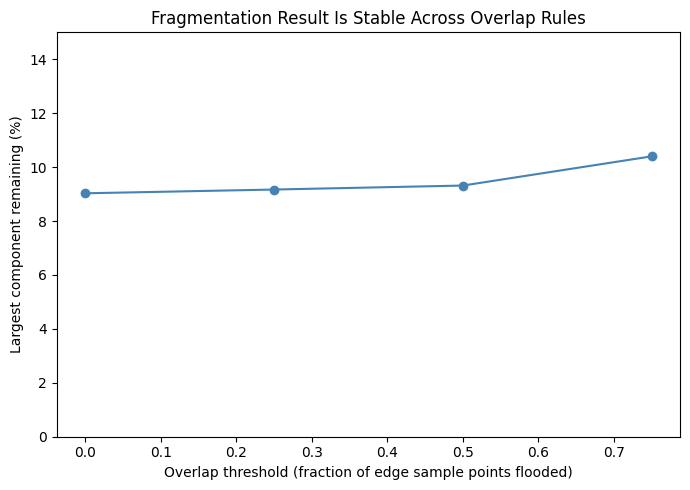

In [3]:
overlap = pd.read_csv(DATA_PROC / 'edge_overlap_sensitivity.csv')
overlap = overlap[overlap['threshold'] < 1.0]  # >=1.0 is a degenerate case, see robustness_checks.md

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(overlap['threshold'], overlap['largest_component_pct'], marker='o', color='steelblue')
ax.set_xlabel('Overlap threshold (fraction of edge sample points flooded)')
ax.set_ylabel('Largest component remaining (%)')
ax.set_title('Fragmentation Result Is Stable Across Overlap Rules')
ax.set_ylim(0, 15)
plt.tight_layout()
plt.show()

**Result:** largest-component-% stays flat (9.0–10.4%) across thresholds spanning a 2× range in edges removed. Not a sampling artifact.

## Continuous capacity vs. leave-one-out

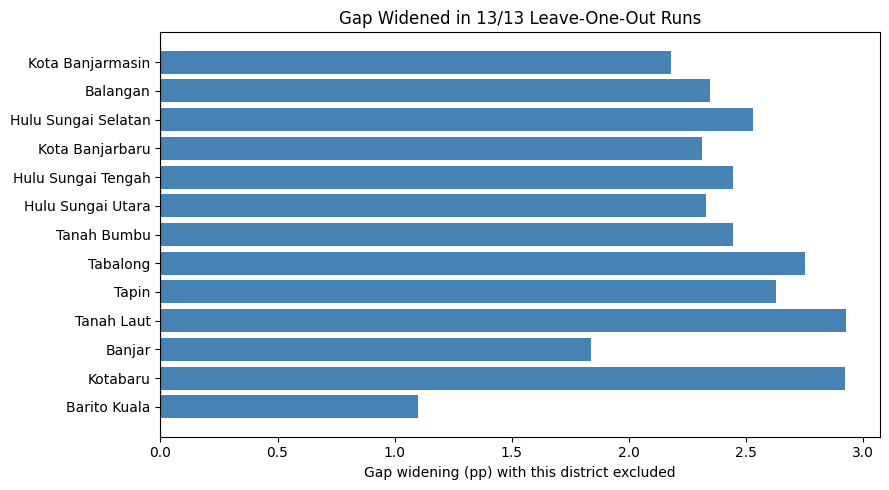

In [4]:
loo = pd.read_csv(DATA_PROC / 'leave_one_out_inequality.csv')
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if w <= 0 else 'steelblue' for w in loo['widening_pp']]
ax.barh(loo['excluded'], loo['widening_pp'], color=colors)
ax.set_xlabel('Gap widening (pp) with this district excluded')
ax.set_title(f"Gap Widened in {(loo['widening_pp']>0).sum()}/{len(loo)} Leave-One-Out Runs")
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Null model A — largest connected component

**This is the check that produced the retraction.** If real floods hit structurally important "chokepoint" edges, the real flood should be *more* damaging than the same number of edges removed uniformly at random.

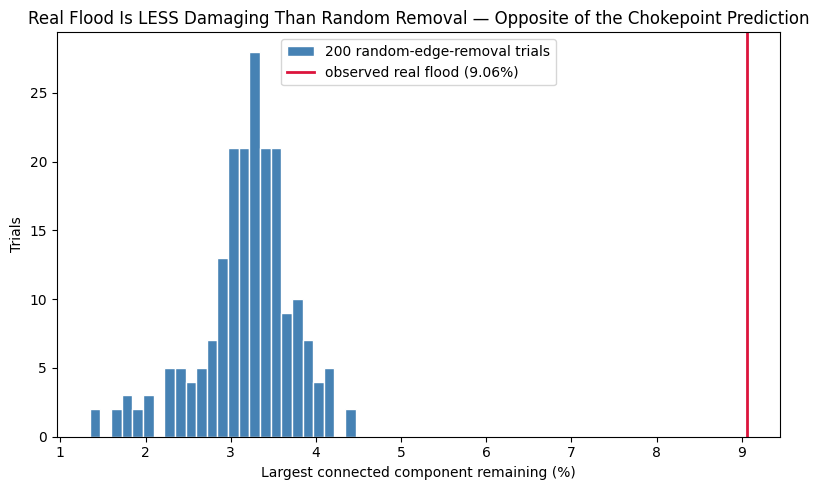

Not one of 200 random trials was as mild as the observed flood.
Wrong-direction test (observed MORE damaging than random): p = 1.0000 (zero support for this direction)
Correct-direction test (observed LESS damaging than random): p = 0.0050


In [5]:
null_a = pd.read_csv(DATA_PROC / 'null_model_random_edges.csv')
with open(DATA_PROC / 'null_model_summary.pickle', 'rb') as f:
    summary_a = pickle.load(f)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(null_a['largest_component_pct'], bins=25, color='steelblue', edgecolor='white',
        label='200 random-edge-removal trials')
ax.axvline(summary_a['observed_largest_pct'], color='crimson', linewidth=2,
            label=f"observed real flood ({summary_a['observed_largest_pct']:.2f}%)")
ax.set_xlabel('Largest connected component remaining (%)')
ax.set_ylabel('Trials')
ax.set_title('Real Flood Is LESS Damaging Than Random Removal — Opposite of the Chokepoint Prediction')
ax.legend()
plt.tight_layout()
plt.show()

n_trials = summary_a['n_trials']
b_reverse = int((null_a['largest_component_pct'] >= summary_a['observed_largest_pct']).sum())
p_reverse = (b_reverse + 1) / (n_trials + 1)
print(f"Not one of {n_trials} random trials was as mild as the observed flood.")
print(f"Wrong-direction test (observed MORE damaging than random): p = {summary_a['p_value']:.4f} (zero support for this direction)")
print(f"Correct-direction test (observed LESS damaging than random): p = {p_reverse:.4f}")

**The chokepoint mechanism is retracted, not reframed.** Full reasoning in `../docs/robustness_checks.md` §7, including why this p-value must be read carefully (the naive p=1.0000 for "observed more damaging than random" means zero support for that direction, not proof against it — the correctly-specified reverse-direction test gives empirical p≈0.005).

## Null A2 — confirms A with an independent metric

Largest-component size isn't the same thing as population losing healthcare access specifically. This reruns the identical randomization with a different damage metric: population disconnected from *any* facility, not just generic graph fragmentation.

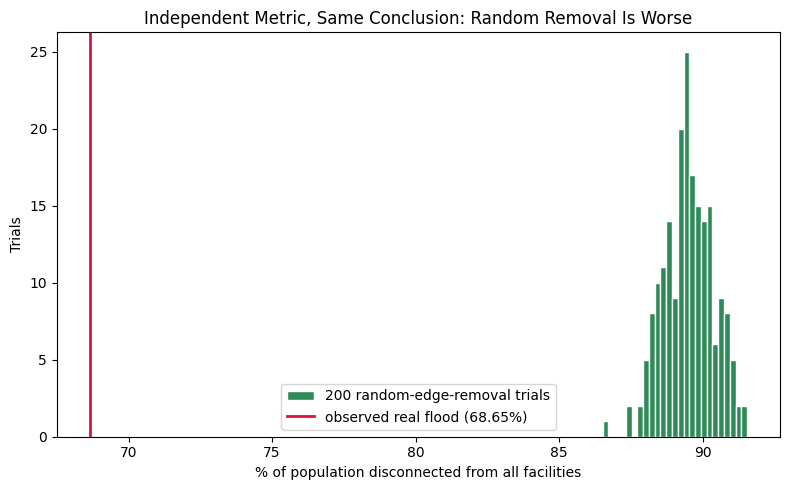

Observed (68.6%) sits BELOW the minimum of all 200 random trials (min=86.5%).
Empirical p (correct direction) ~= 0.0050


In [6]:
null_a2 = pd.read_csv(DATA_PROC / 'null_model_a2_facility_access.csv')
with open(DATA_PROC / 'null_model_a2_summary.pickle', 'rb') as f:
    summary_a2 = pickle.load(f)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(null_a2['pop_disconnected_pct'], bins=25, color='seagreen', edgecolor='white',
        label='200 random-edge-removal trials')
ax.axvline(summary_a2['observed_pct'], color='crimson', linewidth=2,
            label=f"observed real flood ({summary_a2['observed_pct']:.2f}%)")
ax.set_xlabel('% of population disconnected from all facilities')
ax.set_ylabel('Trials')
ax.set_title('Independent Metric, Same Conclusion: Random Removal Is Worse')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Observed ({summary_a2['observed_pct']:.1f}%) sits BELOW the minimum of all "
      f"{summary_a2['n_trials']} random trials (min={summary_a2['trial_min']:.1f}%).")
print(f"Empirical p (correct direction) ~= {summary_a2['p_reverse']:.4f}")

**This confirms Null A rather than complicating it.** Generic network fragmentation and healthcare-specific disconnection could have diverged — they didn't. Both metrics agree the real flood is less disruptive than random removal.

One more thing surfaced while building this check, and it turned out to be more than a discrepancy to document: the observed value here (68.65%) originally didn't match the "94.0% disconnected" figure the severe-scenario headline pipeline reported for the same real scenario. Digging into why found a real pathing bug — the headline pipeline restricted Dijkstra to the single largest post-disruption fragment, silently miscounting population stranded in a smaller-but-facility-served fragment as disconnected. `networkx` handles disconnected graphs correctly on its own, so the fix was to remove that restriction. Fixed in `../src/06_flood_disruption.py` and `../src/11_flood_disruption_sentinel1.py`, rerun end to end: the corrected headline figure is now **68.6%**, matching this check's independently-computed 68.65% almost exactly. See `../docs/robustness_checks.md` §7b–§7c for the full account. The core proxy-vs-observed comparison survives the correction (68.6% > 51.6%, both corrected) — smaller in magnitude than the original buggy 94.0%/74.0% figures, but the same direction.

## What actually survived this review process

1. **Chronic inequality** — solid, unaffected by anything in this notebook.
2. **Disaster amplification, and the proxy overstating its magnitude** — strengthened by the matched-penalty sweep.
3. **The chokepoint mechanism** — retracted. Two independent null models rejected it, not just one.

The empirical fact that motivated the retracted finding — the real flood disconnects more of the population from facilities than the proxy despite affecting fewer roads — is still true and still unexplained. That's an open question for future work, stated as one, not dressed up as an answer.